# Comparative analysis of machine learning models using EPANET datasets in water infrastructure

## Network file description and additional information ##

The Water Sensor Network 1 system is a hypothetical network created as part of a Battle of the Networks aimed to optimize water network design. The system has a total system demand of 1.3 million gallons per day (MGD) (~4921035 Liters per day), one reservoir, two pump stations, two tanks, and 23.3 miles of pipe. It is classified as transmission dense-loop by Hwang & Lansey (2017) and Hoagland et al. (2015).(Ostfeld, 2021)

The Water Sensor Network 1 system comes with four scenarions/patterns which dictate the analysis time and demand (to be more specific, the demand multiplier, which then deviates system demand). For the analysis scenario, 'PATTERN-0' is chosen, since it roughly resembles typical water demand of a network with ebbs and peaks in daily demand. PATTERN-0 spans over a time period of 96 hours. 

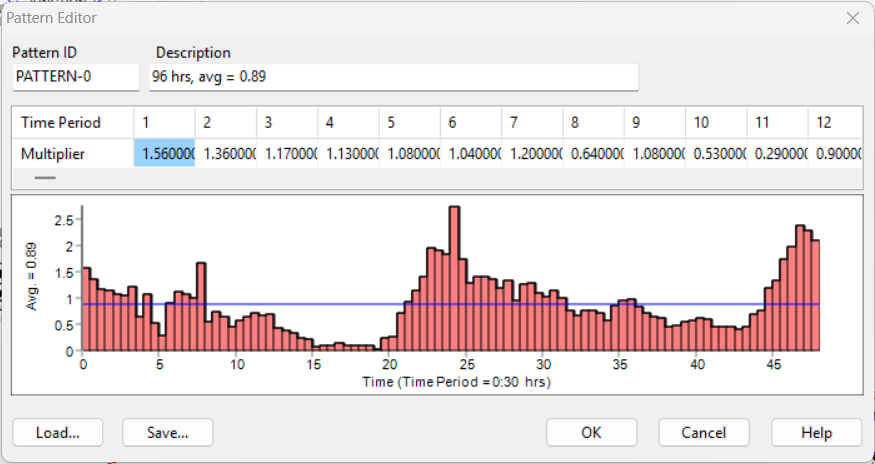

<sub>**Figure 2:** PATTERN-0 demand multiplier curve over 96 hours, showing daily cyclical water demand patterns.</sub>

## EPANET Anaylsis settings

EPANET has several settings that impact how an analysis of the water network. The Analysis Settings can be accessed via the data browser and are as follows:

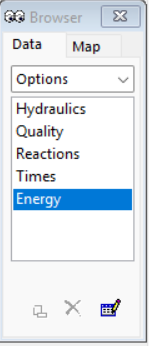

<sub>**Figure 3:** EPANET data browser interface for accessing analysis settings.</sub>

For this analysis, we will concetrate on the Hydraulics and Times options. Hydraulics options include options for flow units, headloss formula (energy loss due to pipe roughness), demand pattern and more. As we use a reference network, we will use the analysis options provided:

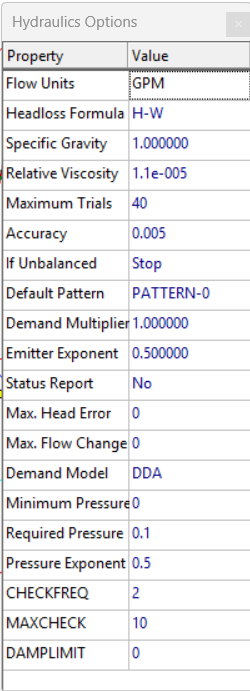 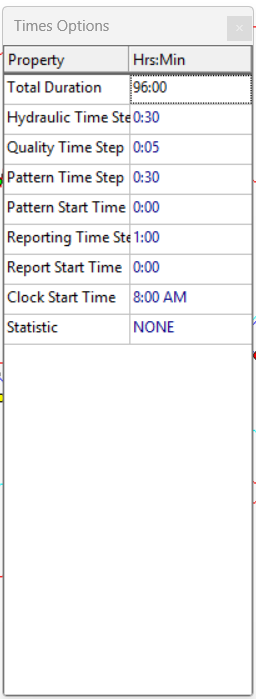

<sub>**Figure 4:** Hydraulics options (left) and Times options (right) configured for the network analysis.</sub>

## Dataset Generation via Simulation Seeding

Rather than ingesting a single 96-hour EPANET report, the dataset is generated directly by running the EPANET hydraulic engine for a 30-day horizon at a 15-minute step (2880 timesteps per node). The demand pattern combines the shape of `PATTERN-0` with per-step lognormal jitter (`σ=0.15`, zero-bias multiplier), mirroring the `Randomizer.randomize_pattern` routine used by the live SCADA application. Each step receives an independent multiplier, so the 30 simulated days are not exact repetitions of the canonical PATTERN-0 cycle.


In [1]:
# Import necessary libraries
import re
import tempfile
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.multioutput import MultiOutputRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
from pygam import GAM
from interpret.glassbox import ExplainableBoostingRegressor
from epyt import epanet
import time

# Containers for model training / inference wall-clock time (seconds)
training_times  = {}
inference_times = {}

# ── Configuration ─────────────────────────────────────────────────────────
SIM_DAYS              = 30
HYDRAULIC_STEP_SEC    = 900                # 15 minutes
PATTERN_SIGMA         = 0.15               # lognormal jitter (Randomizer default)
TOTAL_STEPS           = SIM_DAYS * 24 * 3600 // HYDRAULIC_STEP_SEC  # 2880
RNG_SEED              = 42

def _find_inp() -> Path:
    """Locate WSN1.inp across the common project paths."""
    for p in [Path("WSN1.inp"),
              Path("../research/EPANet Analyse/WSN1.inp"),
              Path("../Steuerungssystem/app/data/WSN1.inp")]:
        if p.exists():
            return p
    raise FileNotFoundError("WSN1.inp not found in any standard location.")

INP_FILE = _find_inp()

# ── Tolerant float parse: some .inp exports use comma decimals ────────────
_DECIMAL_FIX = re.compile(r"(\d),(\d)")

def _normalize_decimals(line: str) -> str:
    """Convert European-locale decimals (`376,07`) to canonical EPANET form (`376.07`)."""
    return _DECIMAL_FIX.sub(r"\1.\2", line)

def _f(s: str) -> float:
    return float(s.replace(",", "."))

# ── PATTERN-0 + lognormal jitter (mirrors app.simulation.Randomizer) ──────
def randomize_pattern(pattern: np.ndarray, sigma: float, rng: np.random.Generator) -> np.ndarray:
    """Zero-bias lognormal multiplier per step; matches Randomizer.randomize_pattern."""
    mu = -0.5 * sigma ** 2
    return pattern * rng.lognormal(mean=mu, sigma=sigma, size=len(pattern))

def parse_node_info(inp_path: Path) -> pd.DataFrame:
    rows, in_section = [], False
    with open(inp_path, encoding="latin-1") as f:
        for line in f:
            s = line.strip()
            if s == "[JUNCTIONS]":
                in_section = True; continue
            if in_section and s.startswith("["):
                break
            if not in_section or s.startswith(";") or not s:
                continue
            parts = s.split()
            if len(parts) >= 3:
                rows.append({
                    "Node":              parts[0],
                    "Elev":              _f(parts[1]),
                    "Base Demand [GPM]": _f(parts[2]),
                    "Pattern":           parts[3] if len(parts) > 3 else "",
                })
    return pd.DataFrame(rows)

def parse_pattern_zero(inp_path: Path) -> list[float]:
    vals, in_section = [], False
    with open(inp_path, encoding="latin-1") as f:
        for line in f:
            s = line.strip()
            if s == "[PATTERNS]":
                in_section = True; continue
            if in_section and s.startswith("["):
                break
            if not in_section or s.startswith(";") or not s:
                continue
            parts = s.split()
            if parts[0] == "PATTERN-0":
                vals.extend(_f(v) for v in parts[1:])
    return vals

def build_jittered_pattern(p0: list[float], total_steps: int,
                           rng: np.random.Generator) -> np.ndarray:
    """
    PATTERN-0 is defined at 0.5-hr resolution. The simulation runs at 15-min
    resolution, so each PATTERN-0 entry covers 2 sim steps. The pattern is
    tiled across `total_steps` and then jittered per step.
    """
    expanded = np.repeat(np.asarray(p0, dtype=float), 2)
    reps = -(-total_steps // len(expanded))   # ceil-div
    tiled = np.tile(expanded, reps)[:total_steps]
    return randomize_pattern(tiled, PATTERN_SIGMA, rng)

def write_prepared_inp(src: Path, dst: Path, jittered: np.ndarray) -> None:
    """
    Emit a clean .inp into `dst`:
      - decimal commas are normalized to periods
      - the original PATTERN-0 lines are stripped and replaced with `jittered`
        chunked at 6 values per line (EPANET's customary width)
    All other sections are passed through verbatim. This sidesteps two crash
    paths: locale-formatted numbers that the C engine can't parse, and
    in-place setPattern() resize past the original buffer length.
    """
    out, in_patterns, replaced = [], False, False
    chunk = 6
    with open(src, encoding="latin-1") as f:
        for raw in f:
            line = _normalize_decimals(raw.rstrip("\n"))
            stripped = line.strip()
            if stripped == "[PATTERNS]":
                out.append(line)
                # Emit our PATTERN-0 immediately after the section header.
                for i in range(0, len(jittered), chunk):
                    seg = jittered[i:i + chunk]
                    out.append(" PATTERN-0\t" + "\t".join(f"{v:.6f}" for v in seg))
                in_patterns = True
                replaced = True
                continue
            if in_patterns and stripped.startswith("["):
                in_patterns = False
            if in_patterns and stripped.startswith("PATTERN-0"):
                continue   # drop original PATTERN-0 rows
            out.append(line)
    if not replaced:
        raise RuntimeError("No [PATTERNS] section found in source .inp")
    dst.write_text("\n".join(out) + "\n", encoding="latin-1")


# ── Run the simulation ────────────────────────────────────────────────────
print(f"Simulating {SIM_DAYS} days at {HYDRAULIC_STEP_SEC // 60}-min step ({TOTAL_STEPS} steps)...")
rng = np.random.default_rng(RNG_SEED)

NodeInfo  = parse_node_info(INP_FILE)
p0        = parse_pattern_zero(INP_FILE)
jittered  = build_jittered_pattern(p0, TOTAL_STEPS, rng)
pat_hours = np.round(np.arange(TOTAL_STEPS) * HYDRAULIC_STEP_SEC / 3600.0, 6)
Patterns  = pd.DataFrame({"hours": pat_hours, "Demand Multiplier": jittered})

# Write a normalized .inp with the jittered PATTERN-0 baked in, then load it.
_tmpdir = Path(tempfile.mkdtemp(prefix="epanet_seed_"))
_prepared = _tmpdir / "WSN1_prepared.inp"
write_prepared_inp(INP_FILE, _prepared, jittered)
print(f"Prepared .inp at {_prepared}")

net = epanet(str(_prepared), loadfile=True)
try:
    net.setTimePatternStep(HYDRAULIC_STEP_SEC)
    net.setTimeHydraulicStep(HYDRAULIC_STEP_SEC)
    net.setTimeReportingStep(HYDRAULIC_STEP_SEC)
    net.setTimeSimulationDuration(SIM_DAYS * 24 * 3600)

    ts        = net.getComputedHydraulicTimeSeries()
    node_ids  = net.getNodeNameID()
    link_ids  = net.getLinkNameID()
    tank_set, res_set = set(net.getNodeTankNameID()), set(net.getNodeReservoirNameID())
    pump_set, valve_set = set(net.getLinkPumpNameID()), set(net.getLinkValveNameID())

    def node_type(nid):
        return "Tank" if nid in tank_set else "Reservoir" if nid in res_set else "Junction"
    def link_type(lid):
        return "Pump" if lid in pump_set else "Valve" if lid in valve_set else "Link"

    node_rows, link_rows = [], []
    for k, t_sec in enumerate(ts.Time):
        t_hr = round(float(t_sec) / 3600.0, 6)
        for ni, nid in enumerate(node_ids):
            node_rows.append({
                "Node":           nid,
                "Node Type":      node_type(nid),
                "Demand":         float(ts.Demand[k][ni]),
                "Head":           float(ts.Head[k][ni]),
                "Pressure [psi]": float(ts.Pressure[k][ni]),
                "hours":          t_hr,
            })
        for li, lid in enumerate(link_ids):
            link_rows.append({
                "Link-ID":            lid,
                "Link Type":          link_type(lid),
                "Flow [GPM]":         float(ts.Flow[k][li]),
                "Velocity [fps]":     float(ts.Velocity[k][li]),
                "Headloss [ft/Kft]":  float(ts.HeadLoss[k][li]),
                "Status":             "Open",
                "hours":              t_hr,
            })
finally:
    try:
        net.unload()
    except Exception:
        pass

JunctionPressures = pd.DataFrame(node_rows)
LinkResults       = pd.DataFrame(link_rows)
# ML pipeline targets junctions only (matches the original 'WSN1 - report.txt' usage).
JunctionPressures = JunctionPressures[JunctionPressures["Node Type"] == "Junction"].copy()
JunctionPressures = JunctionPressures.merge(NodeInfo, on="Node", how="left")


JunctionPressures.drop(columns=["Pattern", "Node Type"], inplace=True)  # redundant Info
print(f"JunctionPressures: {len(JunctionPressures):>9,} rows | columns={list(JunctionPressures.columns)}")
print()
print(JunctionPressures.describe())


Simulating 30 days at 15-min step (2880 steps)...
Prepared .inp at C:\Users\kevin\AppData\Local\Temp\epanet_seed_1jd63k2g\WSN1_prepared.inp
EPANET version 20305 loaded (EPyT version v2.3.5.0 - Last Update: 20/02/2026).
Publication DOI: https://zenodo.org/records/18484878
Input File WSN1_prepared.inp loaded successfully.

Close toolkit for the input file "WSN1_prepared". EPANET Toolkit is unloaded.

JunctionPressures:   374,472 rows | columns=['Node', 'Demand', 'Head', 'Pressure [psi]', 'hours', 'Elev', 'Base Demand [GPM]']

              Demand           Head  Pressure [psi]          hours  \
count  374472.000000  374472.000000   374472.000000  374472.000000   
mean        7.142467     818.258326      103.843505     360.599798   
std        26.458474     141.945322       58.536797     208.096057   
min         0.000000     424.592834        4.191598       0.000000   
25%         0.000000     856.001465       88.220184     180.437500   
50%         0.795561     857.746338      100.93744

## Data Analysis - Pressure Prediction using XGBoost algorithm

### 3. Feature Engineering
### Encoding the "Node" Column and Merging Demand Patterns

In [2]:
JunctionPressures['Demand_to_Elev_ratio'] = JunctionPressures['Base Demand [GPM]'] / (JunctionPressures['Elev'] + 1e-6)


### Create Time Lags for Features

For training purposes a time lag is created for time dependent features so the model can learn to interpret delayed effects.

In [3]:
#Create per Node lag features
lags = [1, 2, 3, 6, 24]
JunctionPressures = JunctionPressures.sort_values(['Node', 'hours'])
for L in lags:
    JunctionPressures[f'Demand_lag{L}']   = JunctionPressures.groupby('Node')['Demand'].shift(L)
    JunctionPressures[f'Head_lag{L}']     = JunctionPressures.groupby('Node')['Head'].shift(L)
    JunctionPressures[f'Press_lag{L}']    = JunctionPressures.groupby('Node')['Pressure [psi]'].shift(L)

# Drop rows where target or lag features are missing
lag_cols = [f'Demand_lag{L}' for L in lags] + [f'Head_lag{L}' for L in lags] + [f'Press_lag{L}' for L in lags]
JunctionPressures = JunctionPressures.dropna(subset=lag_cols).copy()

### Defining Features, Targets and Train-Test Splitting

The dataset is partitioned with a temporal split to evaluate realistic forecasting performance. Because lag features with a maximum lag of 24 positions require dropping the earliest rows of each node, the usable observations begin a few hours into the simulation rather than at hour 0.

The cutoff is computed as **20% of the available hour range**: training uses the earliest 20% of hours after the lag drop, and testing uses the remaining 80%. The split shifts automatically with the dataset length, so the 15-min, 30-day seed produces a substantially larger absolute training window than the original 96-hour report while preserving the same temporal forecasting ratio.

In [20]:
# Define features and target
features = ['Node', 'hours', 'Elev', 'Base Demand [GPM]', 'Demand_to_Elev_ratio']
targets = ['Pressure [psi]','Demand','Head']

X = JunctionPressures[features + lag_cols].copy()
Y = JunctionPressures[targets + ['hours']]

# XGBoost rejects '[', ']', '<' in feature names. Sanitize once here so every
# downstream model (including the SHAP/permutation feature lists) uses the
# cleaned names consistently.
X.columns = (
    X.columns.str.replace('[', '', regex=False)
             .str.replace(']', '', regex=False)
             .str.replace(' ', '_')
)

# Temporal train-test split: first 20% of the available hour range trains, remaining 80% tests.
TRAIN_FRACTION = 0.20
h_min, h_max = X['hours'].min(), X['hours'].max()
split_hour = h_min + TRAIN_FRACTION * (h_max - h_min)
print(f'Train/test cutoff at hour {split_hour:.2f} (range {h_min:.2f}-{h_max:.2f})')

train_mask = X['hours'] <= split_hour
test_mask  = X['hours'] >  split_hour

# Keep node IDs separately (aligned by index); drop 'Node' before training so models receive only numeric features.
node_train = X.loc[train_mask, 'Node']
node_test  = X.loc[test_mask,  'Node']

X_train = X[train_mask].drop(columns=['Node'])
X_test  = X[test_mask ].drop(columns=['Node'])
Y_train = Y[train_mask][targets]
Y_test  = Y[test_mask ][targets]

Y_train.shape, X_train.shape, Y_test.shape, X_test.shape

Train/test cutoff at hour 148.40 (range 5.50-720.00)


((73962, 3), (73962, 19), (297486, 3), (297486, 19))

### XGBoost Regression Model

XGBoost is a distributed gradient boosting library (Tianqi et al., 2016) used for regression, classification and ranking for Python, C++, Java, R, Julia, Pearl and Scala. XGBoost implements gradient-boosted desicion trees that iteratively minimize a differential loss function of reweighted training data. (Friedmann et al., 2000). For this regression task, the xgboost python library is used for supervised learning. Tree complexity and regularization were selected empirically via tuning.

In [22]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import gp_minimize
from sklearn.model_selection import cross_val_score
import numpy as np

xgb_space = [
    Integer(1500, 3000,                   name='n_estimators'),
    Real(00.5, 1.0,                       name='subsample'),
    Real(00.01, 0.3,                      name='eta'),
    Real(00.1, 1.0,                       name='colsample_bytree'),
    Integer(1, 10,                       name='min_child_weight'),
    Real(1e-3, 10, prior='log-uniform',  name='reg_lambda'),
]

@use_named_args(xgb_space)
def xgb_objective(**params):
    base = xgb.XGBRegressor(
        tree_method='hist',
        n_jobs=-1,
        random_state=0,
        **params,
    )
    model = MultiOutputRegressor(base)
    # cv=3 keeps runtime tractable; n_jobs=1 on CV to avoid oversubscribing XGB's threads
    score = cross_val_score(model, X_train, Y_train, cv=3, scoring='r2', n_jobs=1)
    return -np.mean(score)

xgb_result = gp_minimize(
    func=xgb_objective,
    dimensions=xgb_space,
    n_calls=25,
    n_initial_points=8,
    random_state=0,
)

best_xgb_params = dict(zip([d.name for d in xgb_space], xgb_result.x))
print("Best XGB CV R2:", -xgb_result.fun)
print("Best XGB params:", best_xgb_params)

Best XGB CV R2: 0.8115941882133484
Best XGB params: {'n_estimators': np.int64(2465), 'subsample': 0.7356615981522439, 'eta': 0.10512008893834218, 'colsample_bytree': 0.5015666952909058, 'min_child_weight': np.int64(4), 'reg_lambda': 5.901426547645519}


In [23]:
best_xgb_params = {
    'n_estimators': 2465,
    'subsample': 0.7356615981522439,
    'eta': 0.10512008893834218,
    'colsample_bytree': 0.5015666952909058,
    'min_child_weight': 4,
    'reg_lambda': 5.901426547645519,
}

# Hyperparameters from gp_minimize search (cell above)
model = xgb.XGBRegressor(
    tree_method='hist',
    n_jobs=-1,
    random_state=0,
    **best_xgb_params,
)

# Model wrapper for multi-output regression
multi_model = MultiOutputRegressor(model)

# Pipeline on numeric features only ('Node' was dropped upstream)
pipe = Pipeline([('model', multi_model)])

_t0 = time.perf_counter()
pipe.fit(X_train, Y_train)
training_times['XGBoost'] = time.perf_counter() - _t0
print(f"XGBoost training time: {training_times['XGBoost']:.3f} s")

XGBoost training time: 21.315 s


### Neural Network Model

Multi-Layer Perceptrons (MLP) are a widely known way to implement neural networks and were introduced in the 1960s. A MLP is a feedforward neural network consisting of an input layer, one or more hidden layers, and an output layer. A layer of the MLP consists Each neuron computes a weighted sum of its inputs followed by a nonlinear activation function. Model parameters are learned by minimizing a loss function that measures the discrepancy between the network’s predictions and the target values, typically using gradient-based optimization.(Alameida, 1997). 

For this supervised learning task, the MLPRegressor from the sklearn library is used. Hyperparameters of the MLPRegressor are set empirically via tuning.


In [27]:
from skopt.space import Real, Integer, Categorical
from skopt.utils import use_named_args
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

search_space = [
    Integer(1, 4, name='n_layers'),         # number of hidden layers
    Integer(1, 800, name='layer1_size'),   # 1st layer neurons
    Real(1e-4, 1e-2, prior='log-uniform', name='learning_rate_init'),
]

@use_named_args(search_space)
def objective(**params):
    sizes = [params['layer1_size'], params['layer2_size'], params['layer3_size'], params['layer4_size']]
    model = MLPRegressor(
        hidden_layer_sizes=tuple(sizes[:params['n_layers']]),
        learning_rate_init=params['learning_rate_init'],
        random_state=0
    )
    # Negative because skopt minimizes, but we want to maximize R²
    score = cross_val_score(model, X_train, Y_train, cv=5, scoring='r2')
    return -np.mean(score)

In [25]:
from skopt import gp_minimize

result = gp_minimize(
    func=objective,
    dimensions=search_space,
    n_calls=50,        # total evaluations
    n_initial_points=10,  # random exploration before Bayesian kicks in
    random_state=0
)

print("Best score:", -result.fun)
print("Best params:", result.x)

best_nn_params = dict(zip([dim.name for dim in search_space], result.x))
print(best_nn_params)

C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\kevin\A

Best score: 0.9722393501224067
Best params: [np.int64(1), np.int64(200), np.int64(11), np.int64(18), np.int64(43), 0.00010125685828543954]
{'n_layers': np.int64(1), 'layer1_size': np.int64(200), 'layer2_size': np.int64(11), 'layer3_size': np.int64(18), 'layer4_size': np.int64(43), 'learning_rate_init': 0.00010125685828543954}


In [26]:
from sklearn.neural_network import MLPRegressor

best_nn_params = {
    'hidden_layer_sizes': (200),
    'activation': 'relu',
    'learning_rate_init': 0.00010125685828543954
}

# Hyperparameters from gp_minimize search (cell above): best CV R2 = 0.9725
mlp = MLPRegressor(
    random_state=0,
    **best_nn_params
)

multi_mlp = MultiOutputRegressor(mlp)

# Pipeline on numeric features only ('Node' was dropped upstream)
nn_pipe = Pipeline([('model', multi_mlp)])

# Train
_t0 = time.perf_counter()
nn_pipe.fit(X_train, Y_train)
training_times['Neural Network'] = time.perf_counter() - _t0
print(f"Neural Network training time: {training_times['Neural Network']:.3f} s")

Neural Network training time: 53.912 s


### Generalized Additive Model

GAMs employ linear predictors composed of smooth functions, potentially nonlinear functions of individual covariates to generate outputs. As Opposed to NN and XGBoost, which are considered "black-box" models, GAMs offer a transparent way of interpretability, since the whole model structure and the contribution of each covariate can be retreived and visualized. GAMs fall under the class of "glass-box" models (Hassija et al., 2024). Each feature is associated with its own learned smooth function and therefore offering insight of how individual inputs influence a GAMs generated outputs. Training involves optimizing each smooth function with a penalized likelihood.(Wood, 2025).

In this implementation, the PyGAM library is used to model the water network's pressure, demand, and head.(Servén et al., 2018)

In [ ]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import gp_minimize
from sklearn.model_selection import cross_val_score
import numpy as np

# Subsample for tuning to keep runtime tractable; the final fit uses the full training set.
TUNE_FRAC_GAM = 0.3
_gam_idx = X_train.sample(frac=TUNE_FRAC_GAM, random_state=42).index
X_tune_gam = X_train.loc[_gam_idx]
Y_tune_gam = Y_train.loc[_gam_idx]

gam_space = [
    Real(0.01, 10.0, prior='log-uniform', name='lam'),
    Integer(10, 30,                       name='n_splines'),
]

@use_named_args(gam_space)
def gam_objective(**params):
    base = GAM(
        lam=params['lam'],
        n_splines=params['n_splines'],
        max_iter=50,
        tol=1e-3,
    )
    model = MultiOutputRegressor(base)
    score = cross_val_score(model, X_tune_gam, Y_tune_gam, cv=3, scoring='r2', n_jobs=1)
    return -np.mean(score)

gam_result = gp_minimize(
    func=gam_objective,
    dimensions=gam_space,
    n_calls=15,
    n_initial_points=5,
    random_state=0,
)

best_gam_params = dict(zip([d.name for d in gam_space], gam_result.x))
print("Best GAM CV R2:", -gam_result.fun)
print("Best GAM params:", best_gam_params)

C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The following error was raised: 'GAM' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order. The default are now used instead since retrieving tags failed. This warning will be replaced by an error in 1.8.
  warnings.warn(
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The follow

Best GAM CV R2: 0.9723928831867906
Best GAM params: {'lam': 10.0, 'n_splines': np.int64(10)}


In [28]:
best_gam_params = {
    'lam': 10,
    'n_splines': 10
}

# Generalized Additive Model (GAM) for multi-output regression
# Hyperparameters from gp_minimize search (cell above)
gam = GAM(
    lam=best_gam_params['lam'],
    n_splines=best_gam_params['n_splines'],
    max_iter=100,
    tol=1e-3,
)

multi_gam = MultiOutputRegressor(gam)

# Pipeline on numeric features only ('Node' was dropped upstream)
gam_pipe = Pipeline([('model', multi_gam)])

# Train
_t0 = time.perf_counter()
gam_pipe.fit(X_train, Y_train)
training_times['GAM'] = time.perf_counter() - _t0
print(f"GAM training time: {training_times['GAM']:.3f} s")

C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The following error was raised: 'GAM' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order. The default are now used instead since retrieving tags failed. This warning will be replaced by an error in 1.8.
  warnings.warn(
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The follow

GAM training time: 10.981 s


### Explainable Boosting Machine

Explainable Boosting Machines (EBMs) are interpretable glass-box models that combine the accuracy of modern gradient boosting with the interpretability of generalized additive models. Developed by Microsoft Research as part of the InterpretML library, EBMs extend traditional GAMs by using gradient boosting and allowing pairwise feature interactions while maintaining full transparency (Nori et al., 2019; Lou et al., 2013). 

Unlike XGBoost, which builds complex trees that are difficult to interpret, EBMs build separate models for each feature and interaction term, making individual contributions directly observable. The algorithm uses round-robin boosting to ensure each feature receives equal representation in the model, preventing feature overshadowing common in traditional boosting methods. This architecture enables EBMs to achieve competitive predictive performance while providing explanations for both global model behavior and individual predictions.

For this supervised learning task, the ExplainableBoostingRegressor from the InterpretML library is used. Hyperparameters including interaction terms, bin sizes, and bagging parameters are set empirically via tuning.

In [ ]:
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from skopt import gp_minimize
from sklearn.model_selection import cross_val_score
import numpy as np

# Tune on the Pressure target only and a subsample, to keep runtime tractable.
# The chosen params are then applied to all three outputs via MultiOutputRegressor.
TUNE_FRAC_EBM = 0.3
_ebm_idx = X_train.sample(frac=TUNE_FRAC_EBM, random_state=42).index
X_tune_ebm = X_train.loc[_ebm_idx]
y_tune_ebm = Y_train.loc[_ebm_idx, 'Pressure [psi]']

ebm_space = [
    Integer(64, 256,                       name='max_bins'),
    Integer(0, 15,                         name='interactions'),
    Real(0.005, 0.1, prior='log-uniform',  name='learning_rate'),
    Integer(2, 6,                          name='max_leaves'),
    Integer(2, 20,                         name='min_samples_leaf'),
]

def _py(params):
    # Cast skopt's numpy scalars to native Python types.
    # InterpretML EBM calls len() on `interactions` and isinstance(int) checks
    # elsewhere; both can break on np.int64 / np.float64.
    out = {}
    for k, v in params.items():
        if isinstance(v, np.integer):
            out[k] = int(v)
        elif isinstance(v, np.floating):
            out[k] = float(v)
        else:
            out[k] = v
    return out

@use_named_args(ebm_space)
def ebm_objective(**params):
    model = ExplainableBoostingRegressor(
        outer_bags=4,
        random_state=0,
        **_py(params),
    )
    score = cross_val_score(model, X_tune_ebm, y_tune_ebm, cv=3, scoring='r2', n_jobs=1)
    return -np.mean(score)

ebm_result = gp_minimize(
    func=ebm_objective,
    dimensions=ebm_space,
    n_calls=15,
    n_initial_points=5,
    random_state=0,
)

best_ebm_params = _py(dict(zip([d.name for d in ebm_space], ebm_result.x)))
print("Best EBM CV R2 (Pressure):", -ebm_result.fun)
print("Best EBM params:", best_ebm_params)


C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\cloudpickle\cloudpickle.py:1303: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  return super().dump(obj)
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\cloudpickle\cloudpickle.py:1303: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  return super().dump(obj)
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\cloudpickle\cloudpickle.py:1303: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  return super().dump(obj)
C:\Users\kevin\AppData\Local\Packages\PythonSo

Best EBM CV R2 (Pressure): 0.999893140591678
Best EBM params: {'max_bins': 158, 'interactions': 10, 'learning_rate': 0.06373051720740458, 'max_leaves': 6, 'min_samples_leaf': 7}


In [29]:
best_ebm_params = {
    'interactions': 10,
    'learning_rate': 0.06373051720740458,
    'max_bins': 158,
    'max_leaves': 6,
    'min_samples_leaf': 7
}

# Explainable Boosting Machine (EBM) for multi-output regression
# Hyperparameters from gp_minimize search (cell above)
ebm = ExplainableBoostingRegressor(
    outer_bags=8,
    random_state=0,
    **best_ebm_params,
)

multi_ebm = MultiOutputRegressor(ebm)

# Pipeline on numeric features only ('Node' was dropped upstream)
ebm_pipe = Pipeline([('model', multi_ebm)])

# Train
_t0 = time.perf_counter()
ebm_pipe.fit(X_train, Y_train)
training_times['EBM'] = time.perf_counter() - _t0
print(f"EBM training time: {training_times['EBM']:.3f} s")

C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\cloudpickle\cloudpickle.py:1303: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  return super().dump(obj)
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\cloudpickle\cloudpickle.py:1303: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  return super().dump(obj)
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\joblib\externals\cloudpickle\cloudpickle.py:1303: DeprecationWarning: Pickle, copy, and deepcopy support will be removed from itertools in Python 3.14.
  return super().dump(obj)
C:\Users\kevin\AppData\Local\Packages\PythonSo

EBM training time: 1039.689 s


### Apply Trained Models to Make Prediction on Test Set

In [30]:
# Predictions
_t0 = time.perf_counter()
y_pred = pipe.predict(X_test)
inference_times['XGBoost'] = time.perf_counter() - _t0
print(f"XGBoost inference time: {inference_times['XGBoost']:.3f} s")
y_pred_df = pd.DataFrame(y_pred, columns=targets)

XGBoost inference time: 5.826 s


In [31]:
_t0 = time.perf_counter()
y_pred_nn = nn_pipe.predict(X_test)
inference_times['Neural Network'] = time.perf_counter() - _t0
print(f"Neural Network inference time: {inference_times['Neural Network']:.3f} s")
y_pred_nn_df = pd.DataFrame(y_pred_nn, columns=targets, index=X_test.index)

Neural Network inference time: 0.448 s


In [32]:
_t0 = time.perf_counter()
y_pred_gam = gam_pipe.predict(X_test)
inference_times['GAM'] = time.perf_counter() - _t0
print(f"GAM inference time: {inference_times['GAM']:.3f} s")
y_pred_gam_df = pd.DataFrame(y_pred_gam, columns=targets, index=X_test.index)

C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The following error was raised: 'GAM' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order. The default are now used instead since retrieving tags failed. This warning will be replaced by an error in 1.8.
  warnings.warn(


GAM inference time: 12.101 s


C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The following error was raised: 'GAM' object has no attribute '__sklearn_tags__'. It seems that there are no classes that implement `__sklearn_tags__` in the MRO and/or all classes in the MRO call `super().__sklearn_tags__()`. Make sure to inherit from `BaseEstimator` which implements `__sklearn_tags__` (or alternatively define `__sklearn_tags__` but we don't recommend this approach). Note that `BaseEstimator` needs to be on the right side of other Mixins in the inheritance order. The default are now used instead since retrieving tags failed. This warning will be replaced by an error in 1.8.
  warnings.warn(
C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\_tags.py:338: DeprecationWarning: The follow

In [33]:
_t0 = time.perf_counter()
y_pred_ebm = ebm_pipe.predict(X_test)
inference_times['EBM'] = time.perf_counter() - _t0
print(f"EBM inference time: {inference_times['EBM']:.3f} s")
y_pred_ebm_df = pd.DataFrame(y_pred_ebm, columns=targets, index=X_test.index)

EBM inference time: 0.184 s


### Model Evaluation


MODEL EVALUATION RESULTS - PRESSURE [PSI]
         Model     RMSE       R2      MSE
       XGBoost 0.524303 0.999920 0.274894
Neural Network 2.941694 0.997475 8.653565
           GAM 1.120322 0.999634 1.255121
           EBM 0.497858 0.999928 0.247863

  Table 5a: Model performance metrics (RMSE, R2, MSE) for
            Pressure [psi] predictions on the test set.


MODEL EVALUATION RESULTS - DEMAND
         Model     RMSE       R2       MSE
       XGBoost 9.639959 0.866593 92.928818
Neural Network 7.664960 0.915657 58.751607
           GAM 7.132065 0.926977 50.866355
           EBM 7.508319 0.919069 56.374852

  Table 5b: Model performance metrics (RMSE, R2, MSE) for
            Demand predictions on the test set.


MODEL EVALUATION RESULTS - HEAD
         Model     RMSE       R2       MSE
       XGBoost 1.824774 0.999835  3.329800
Neural Network 4.210709 0.999120 17.730069
           GAM 2.585541 0.999668  6.685021
           EBM 1.114039 0.999938  1.241083

  Table 5c: Model perfor

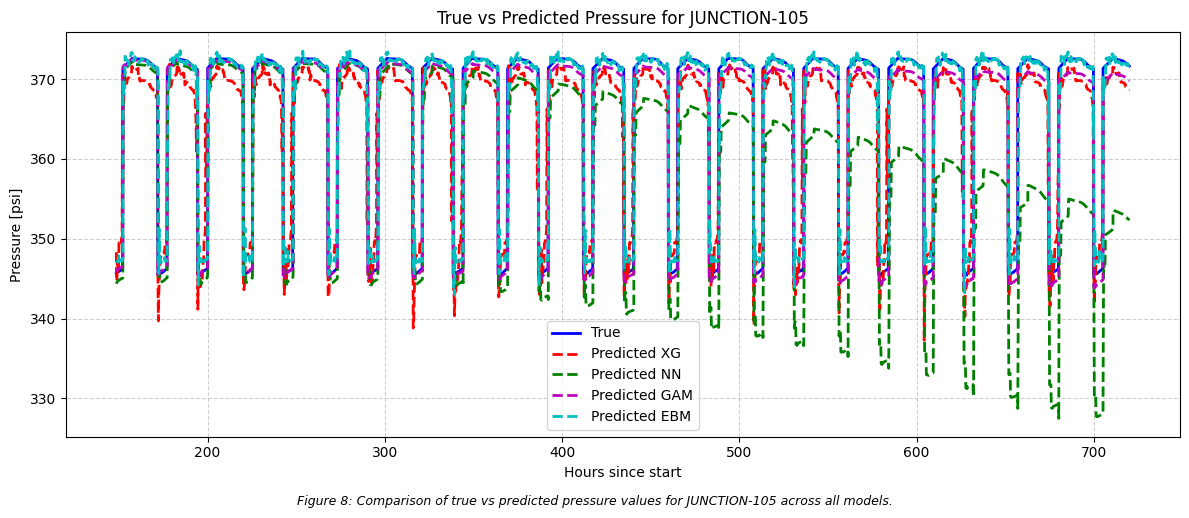


PRESSURE EVALUATION FOR JUNCTION-105
------------------------------------------------------------
         Model     RMSE       R2       MSE
       XGBoost 4.142318 0.862294 17.158794
Neural Network 9.902405 0.213050 98.057635
           GAM 3.697876 0.890259 13.674290
           EBM 3.590315 0.896550 12.890359
------------------------------------------------------------

  Table 6: Pressure prediction metrics for JUNCTION-105.
           Node-specific evaluation of model accuracy.



In [34]:
# Re-attach node IDs to predictions for per-node evaluation
def attach_results(X_te, y_pred_df, node_ids, y_true):
    df = X_te.copy()
    df['Node'] = node_ids
    df['TruePressure']      = y_true['Pressure [psi]'].values
    df['PredictedPressure'] = y_pred_df['Pressure [psi]'].values
    df['TrueDemand']        = y_true['Demand'].values
    df['PredictedDemand']   = y_pred_df['Demand'].values
    df['TrueHead']          = y_true['Head'].values
    df['PredictedHead']     = y_pred_df['Head'].values
    return df

test_results     = attach_results(X_test, y_pred_df,     node_test, Y_test)
test_results_nn  = attach_results(X_test, y_pred_nn_df,  node_test, Y_test)
test_results_gam = attach_results(X_test, y_pred_gam_df, node_test, Y_test)
test_results_ebm = attach_results(X_test, y_pred_ebm_df, node_test, Y_test)

# Evaluation metrics for all models, reported per target variable.
# Pooling RMSE/MSE across targets mixes units (psi, GPM, ft) and lets the
# largest-scale target dominate, so each target gets its own table instead.
model_predictions = {
    'XGBoost':        y_pred,
    'Neural Network': y_pred_nn,
    'GAM':            y_pred_gam,
    'EBM':            y_pred_ebm,
}

per_target_rows = {t: [] for t in targets}
for model_name, pred in model_predictions.items():
    mse_each = mean_squared_error(Y_test, pred, multioutput='raw_values')
    r2_each  = r2_score(Y_test, pred, multioutput='raw_values')
    for target, mse_t, r2_t in zip(targets, mse_each, r2_each):
        per_target_rows[target].append({
            'Model': model_name,
            'RMSE': np.sqrt(mse_t),
            'R2': r2_t,
            'MSE': mse_t,
        })

evaluation_results_per_target = {t: pd.DataFrame(rows) for t, rows in per_target_rows.items()}

for sub, target in zip('abc', targets):
    table = evaluation_results_per_target[target]
    print("\n" + "="*60)
    print(f"MODEL EVALUATION RESULTS - {target.upper()}")
    print("="*60)
    print(table.to_string(index=False))
    print("="*60)
    print(f"\n  Table 5{sub}: Model performance metrics (RMSE, R2, MSE) for")
    print(f"            {target} predictions on the test set.\n")

# Evaluation & Visualization for a specific Node
node_name = 'JUNCTION-105'
node_df     = test_results[test_results['Node'] == node_name].copy()
node_df_nn  = test_results_nn[test_results_nn['Node'] == node_name].copy()
node_df_gam = test_results_gam[test_results_gam['Node'] == node_name].copy()
node_df_ebm = test_results_ebm[test_results_ebm['Node'] == node_name].copy()

# Pressure Plot
plt.figure(figsize=(12,5))
plt.plot(node_df['hours'], node_df['TruePressure'], 'b-', label='True', linewidth=2)
plt.plot(node_df['hours'], node_df['PredictedPressure'], 'r--', label='Predicted XG', linewidth=2)
plt.plot(node_df_nn['hours'], node_df_nn['PredictedPressure'], 'g--', label='Predicted NN', linewidth=2)
plt.plot(node_df_gam['hours'], node_df_gam['PredictedPressure'], 'm--', label='Predicted GAM', linewidth=2)
plt.plot(node_df_ebm['hours'], node_df_ebm['PredictedPressure'], 'c--', label='Predicted EBM', linewidth=2)
plt.xlabel('Hours since start')
plt.ylabel('Pressure [psi]')
plt.title(f'True vs Predicted Pressure for {node_name}')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.figtext(0.5, -0.02, f'Figure 8: Comparison of true vs predicted pressure values for {node_name} across all models.',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

# Pressure Evaluation Metrics for the specific Node
node_press_mse = mean_squared_error(node_df['TruePressure'], node_df['PredictedPressure'])
node_press_rmse = np.sqrt(node_press_mse)
node_press_r2 = r2_score(node_df['TruePressure'], node_df['PredictedPressure'])

node_press_mse_nn = mean_squared_error(node_df_nn['TruePressure'], node_df_nn['PredictedPressure'])
node_press_rmse_nn = np.sqrt(node_press_mse_nn)
node_press_r2_nn = r2_score(node_df_nn['TruePressure'], node_df_nn['PredictedPressure'])

node_press_mse_gam = mean_squared_error(node_df_gam['TruePressure'], node_df_gam['PredictedPressure'])
node_press_rmse_gam = np.sqrt(node_press_mse_gam)
node_press_r2_gam = r2_score(node_df_gam['TruePressure'], node_df_gam['PredictedPressure'])

node_press_mse_ebm = mean_squared_error(node_df_ebm['TruePressure'], node_df_ebm['PredictedPressure'])
node_press_rmse_ebm = np.sqrt(node_press_mse_ebm)
node_press_r2_ebm = r2_score(node_df_ebm['TruePressure'], node_df_ebm['PredictedPressure'])

# Pressure evaluation table
pressure_eval = pd.DataFrame({
    'Model': ['XGBoost', 'Neural Network', 'GAM', 'EBM'],
    'RMSE': [node_press_rmse, node_press_rmse_nn, node_press_rmse_gam, node_press_rmse_ebm],
    'R2': [node_press_r2, node_press_r2_nn, node_press_r2_gam, node_press_r2_ebm],
    'MSE': [node_press_mse, node_press_mse_nn, node_press_mse_gam, node_press_mse_ebm]
})

print(f"\nPRESSURE EVALUATION FOR {node_name}")
print("-"*60)
print(pressure_eval.to_string(index=False))
print("-"*60)
print(f"\n  Table 6: Pressure prediction metrics for {node_name}.")
print("           Node-specific evaluation of model accuracy.\n")



MODEL TIME (training vs inference)
------------------------------------------------------------
         Model  Training [s]  Inference [s]  Total [s]
       XGBoost      4.414399       3.290664   7.705063
Neural Network     27.996260       0.673274  28.669533
           GAM      1.386768       2.563767   3.950535
           EBM    934.197033       0.067500 934.264533
------------------------------------------------------------


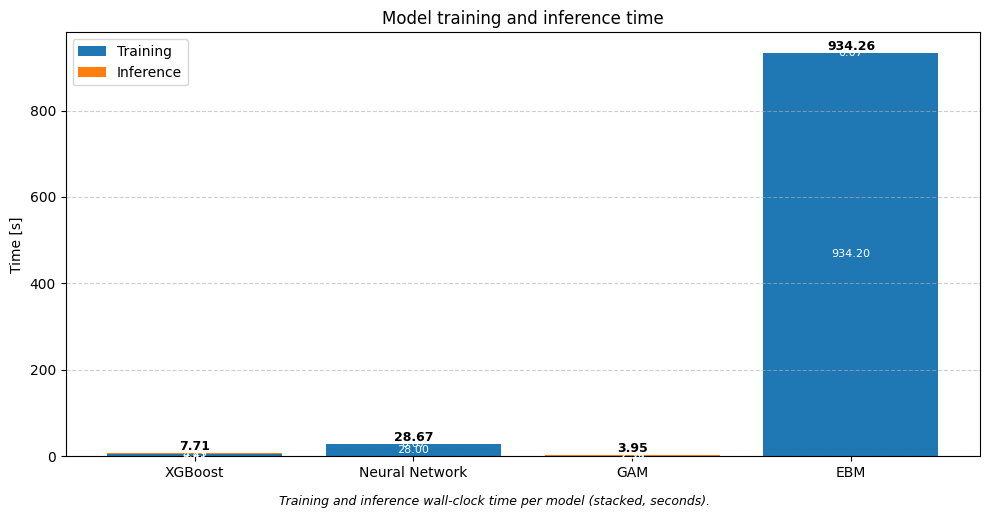

In [15]:
# Training & inference time per model
# Wall-clock times recorded during the fit and predict steps above are
# summed per model and shown as a stacked bar chart (training + inference),
# color-coded by phase.
timing_models = ['XGBoost', 'Neural Network', 'GAM', 'EBM']
train_t = np.array([training_times.get(m, np.nan)  for m in timing_models])
infer_t = np.array([inference_times.get(m, np.nan) for m in timing_models])

timing_df = pd.DataFrame({
    'Model': timing_models,
    'Training [s]':  train_t,
    'Inference [s]': infer_t,
})
timing_df['Total [s]'] = timing_df['Training [s]'] + timing_df['Inference [s]']

print("\nMODEL TIME (training vs inference)")
print("-" * 60)
print(timing_df.to_string(index=False))
print("-" * 60)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(timing_models))
ax.bar(x, train_t, color='#1f77b4', label='Training')
ax.bar(x, infer_t, bottom=train_t, color='#ff7f0e', label='Inference')
ax.set_xticks(x)
ax.set_xticklabels(timing_models)
ax.set_ylabel('Time [s]')
ax.set_title('Model training and inference time')
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Annotate each segment and the stacked total.
for xi, tr, inf in zip(x, train_t, infer_t):
    if tr > 0:
        ax.text(xi, tr / 2, f'{tr:.2f}', ha='center', va='center', color='white', fontsize=8)
    if inf > 0:
        ax.text(xi, tr + inf / 2, f'{inf:.2f}', ha='center', va='center', color='white', fontsize=8)
    ax.text(xi, tr + inf, f'{tr + inf:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.figtext(0.5, -0.02,
            'Training and inference wall-clock time per model (stacked, seconds).',
            ha='center', fontsize=9, style='italic')
plt.tight_layout()
plt.show()

### Evaluation Remarks



From the overall evaluation metrics, the Neural Network clearly emerges as the top performer, followed by XGBoost, followed by EBM and GAM showing weaker performance. The R² scores across all the three top perfomers,  remain relatively high (typically > 0.90).

The Neural Network demonstrates the strongest prediction capabilites with consistently low error metrics across all three target variables (Pressure, Demand, and Head). XGBoost performs as a second-place contender, showing predictions with only marginally higher errors than the Neural Network.

The EMB, despite its interpretability advantages, shows weaker performance compared to both Neural Network and XGBoost. All evaluation metrics (RMSE, R², MSE) consistently indicate that EBM struggles to achieve the same level of accuracy as the leading models. This performance gap suggests that EBM's generalized additive structure with pairwise interactions may be insufficient to fully capture the interactions present in hydraulic systems.

The GAM shows the worst performance compared to the three top performers. GAMs provide excellent interpretability through smooth functions, but their inherent assumption of additive separability limits their ability to capture the complex interactions present in water distribution systems. The performance gap indicates that hydraulic variables interact in ways that cannot be adequately represented as sums of univariate smooth functions.

## Explainability

Understanding why models make certain predictions is crucial for operational decision-making in water distribution systems. While Neural Networks and XGBoost offer superior predictive performance, their complexity makes interpretation challenging. This section explores post-hoc explainability techniques to provide insights into model behavior and feature contributions.

To study explainability, two methods are used. SHAP uses game-theoretic Shapley values to assign each feature an additive contribution to a prediction, revealing how inputs push an output away from the baseline. Permutation importance measures feature influence by observing the drop in performance when a feature’s values are randomly shuffled, capturing effects that arise through both main contributions and interactions. Together, these methods highlight which hydraulic parameters (elevation, demand multiplier, lag features, etc.) drive predictions and let operators verify that the models are learning relationships that are physically meaningful.

### SHAP Values Analysis

SHAP values provide a unified measure of feature importance based on cooperative game theory. For each prediction, SHAP values show how much each feature contributed to moving the prediction away from the average baseline prediction. Positive SHAP values push predictions higher, while negative values push them lower.(Lundberg & Lee, 2017)

The analysis of SHAP values reveals distinct patterns in how each model leverages features for pressure prediction. A common trend across all models is the significant contribution of lag values, which are critical for enhancing prediction accuracy. However, the prioritization of these lags varies: XGBoost, EBM, and GAM consistently rank pressure lags as the most influential features, whereas the NN assigns greater importance to head lags.

Notably, while most models (excluding XGBoost) identify elevation as an important feature, the Neural Network effectively integrates the importance of elevation with head lags. Given the direct hydraulic relationship between these variables and pressure, this synergy likely underpins the NN's superior predictive performance. In contrast, XGBoost appears to function as a physically agnostic model, deriving its predictions almost exclusively from pressure lags without assigning significant weight to physical constraints like elevation. This reliance risks reducing the model to a statistical "black box," potentially limiting its generalizability if the network's physical configuration, such as node elevations, were to change.

Furthermore, all ensemble models exhibit some reliance on specific junction identifiers, suggesting they have captured certain spatial relationships within the network. The Explainable Boosting Machine (EBM) places the highest importance on individual junctions, indicating a more developed spatial understanding compared to other models. This characteristic may stem from EBM's architecture, which forces the boosting of each feature, whereas XGBoost selectively boosts only the most effective trees, making it prone to feature overshadowing.

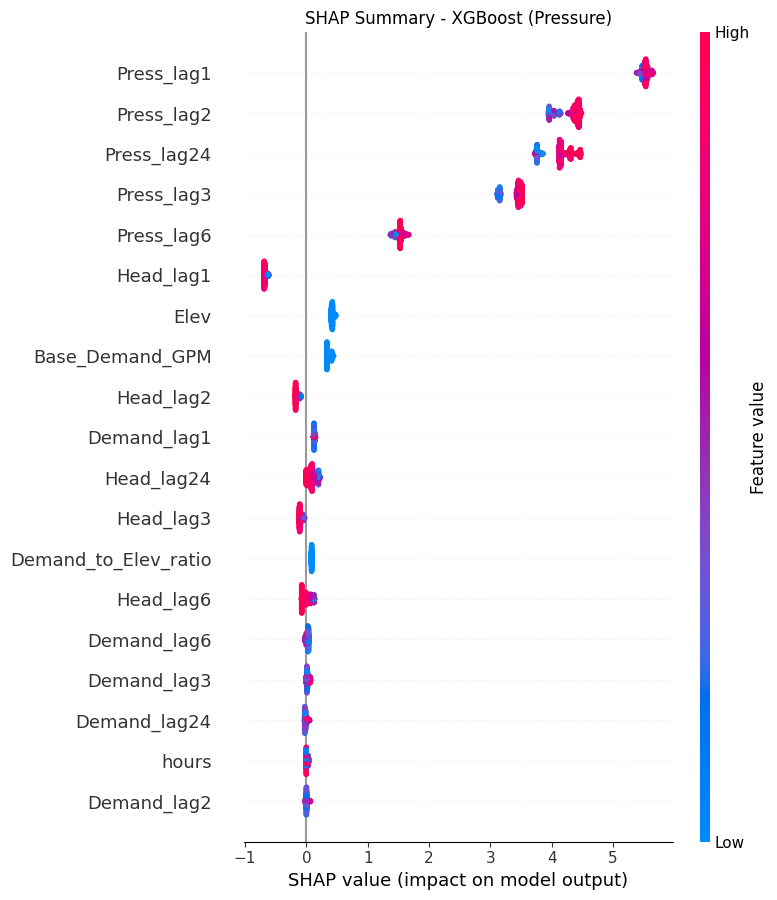

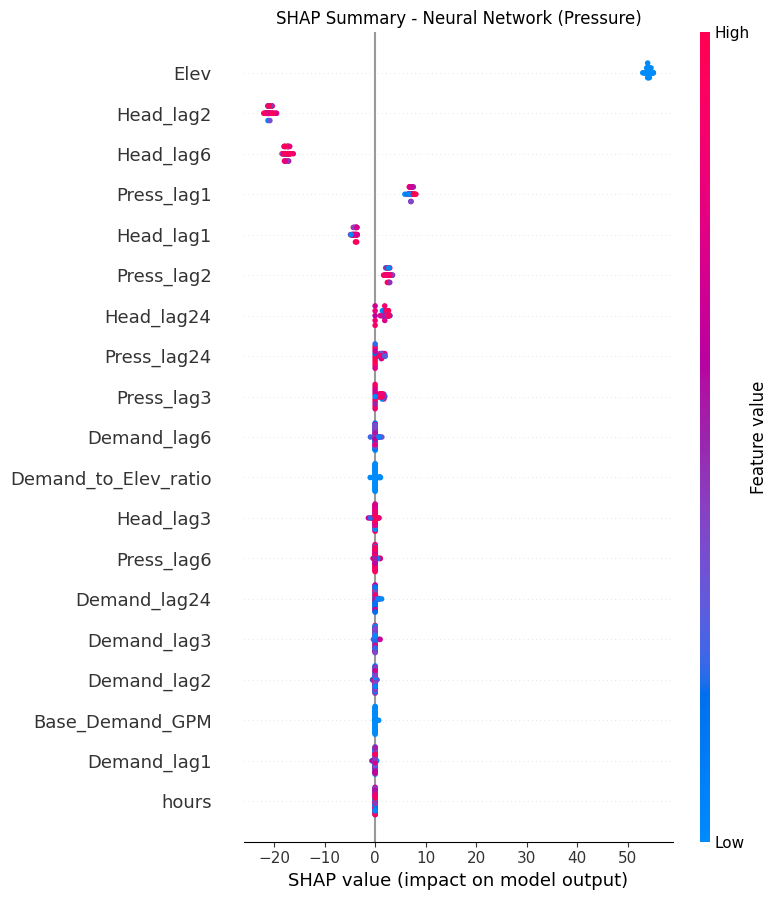

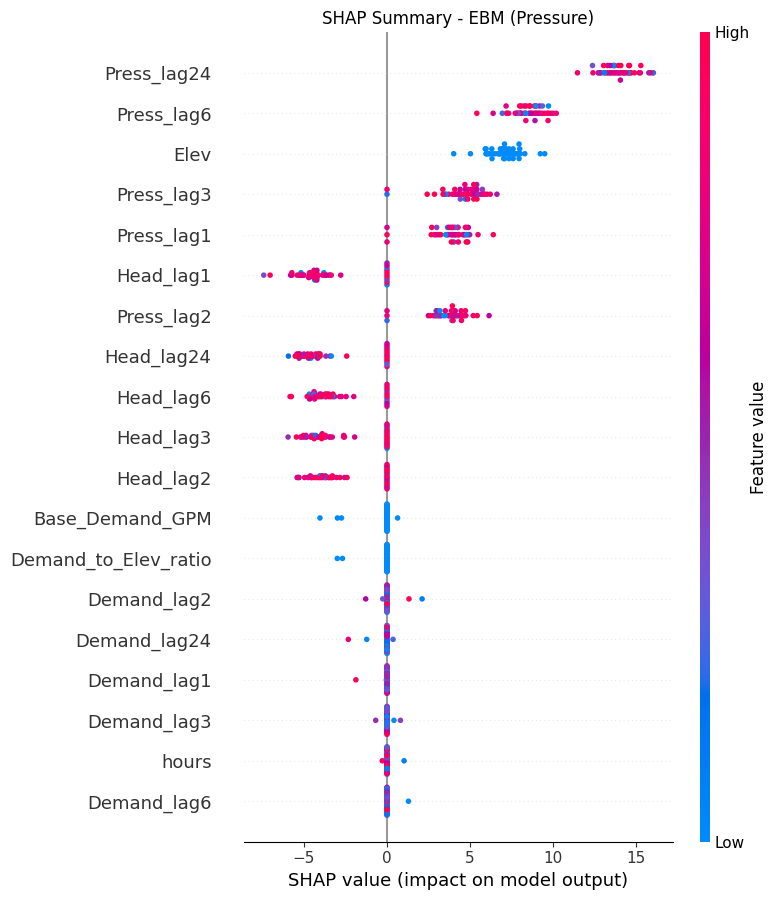

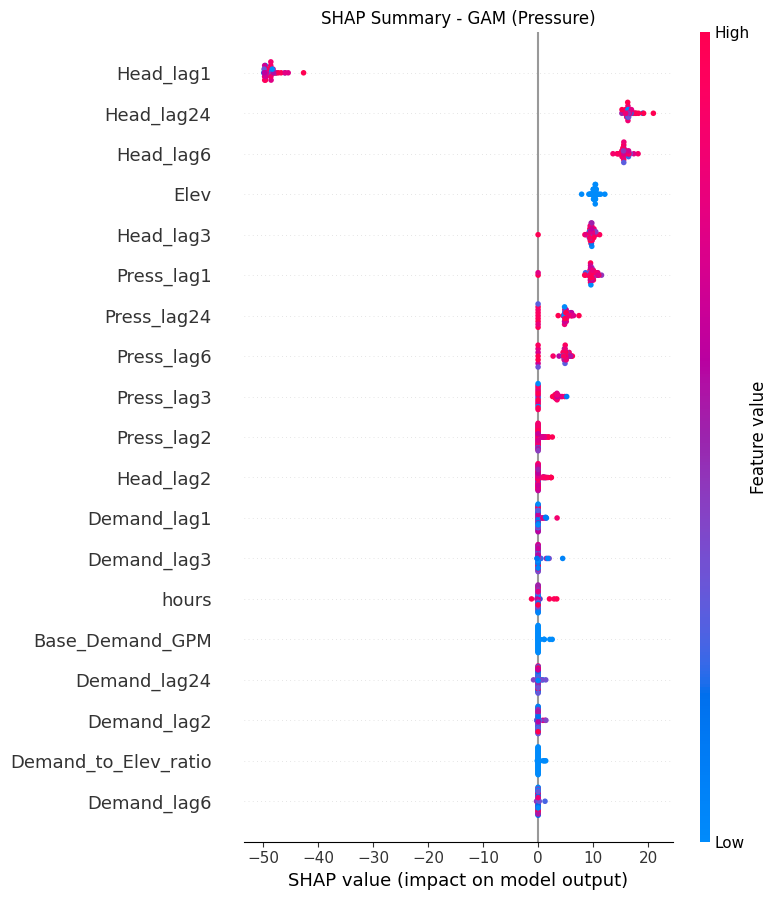

In [35]:
import shap
import warnings

# SHAP Analysis for All Models (Pressure Prediction)

# Numeric features only (no preprocessing step in the pipelines anymore)
X_train_processed = X_train.values
X_test_processed  = X_test.values
all_feature_names = list(X_train.columns)

# Extract models for each target
pressure_model = pipe.named_steps['model'].estimators_[0]
demand_model   = pipe.named_steps['model'].estimators_[1]
head_model     = pipe.named_steps['model'].estimators_[2]

# Sample sizes for efficiency (reduced for faster computation)
n_background = 50      # Background samples for KernelExplainer
n_test_samples = 50    # Test samples to explain
n_shap_samples = 100   # Number of perturbation samples per explanation

# Create background sample for KernelExplainer-based models
background_sample = shap.sample(X_train_processed, n_background)
background_df = pd.DataFrame(background_sample, columns=all_feature_names)

# 1. XGBoost SHAP (TreeExplainer)
explainer_pressure = shap.TreeExplainer(pressure_model)
shap_values_pressure = explainer_pressure.shap_values(X_test_processed[:500])

# 2. Neural Network SHAP (KernelExplainer)
nn_pressure_model = nn_pipe.named_steps['model'].estimators_[0]
explainer_nn_pressure = shap.KernelExplainer(nn_pressure_model.predict, background_sample)
shap_values_nn_pressure = explainer_nn_pressure.shap_values(X_test_processed[:n_test_samples], nsamples=n_shap_samples, silent=True)

# 3. EBM SHAP (KernelExplainer - using numpy arrays to avoid feature name warnings)
ebm_pressure_model = ebm_pipe.named_steps['model'].estimators_[0]

# Suppress the InterpretML feature name warning for EBM
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='.*does not contain all feature names.*')

    def ebm_predict_wrapper(X_array):
        """Wrapper to handle EBM prediction with numpy arrays."""
        return ebm_pressure_model.predict(X_array)

    explainer_ebm_pressure = shap.KernelExplainer(ebm_predict_wrapper, background_sample)
    shap_values_ebm_pressure = explainer_ebm_pressure.shap_values(X_test_processed[:n_test_samples], nsamples=n_shap_samples, silent=True)

# 4. GAM SHAP (KernelExplainer - optimized with reduced samples)
gam_pressure_model = gam_pipe.named_steps['model'].estimators_[0]
explainer_gam_pressure = shap.KernelExplainer(gam_pressure_model.predict, background_sample)
shap_values_gam_pressure = explainer_gam_pressure.shap_values(X_test_processed[:n_test_samples], nsamples=n_shap_samples, silent=True)

# SHAP Summary Plots - one figure per model
import matplotlib.pyplot as plt

models_shap = [
    ("XGBoost",        shap_values_pressure,     X_test_processed[:500]),
    ("Neural Network", shap_values_nn_pressure,  X_test_processed[:n_test_samples]),
    ("EBM",            shap_values_ebm_pressure, X_test_processed[:n_test_samples]),
    ("GAM",            shap_values_gam_pressure, X_test_processed[:n_test_samples]),
]

for name, sv, X_data in models_shap:
    plt.figure()
    shap.summary_plot(sv, X_data, feature_names=all_feature_names, show=False)
    plt.title(f"SHAP Summary - {name} (Pressure)")
    plt.tight_layout()
    plt.show()


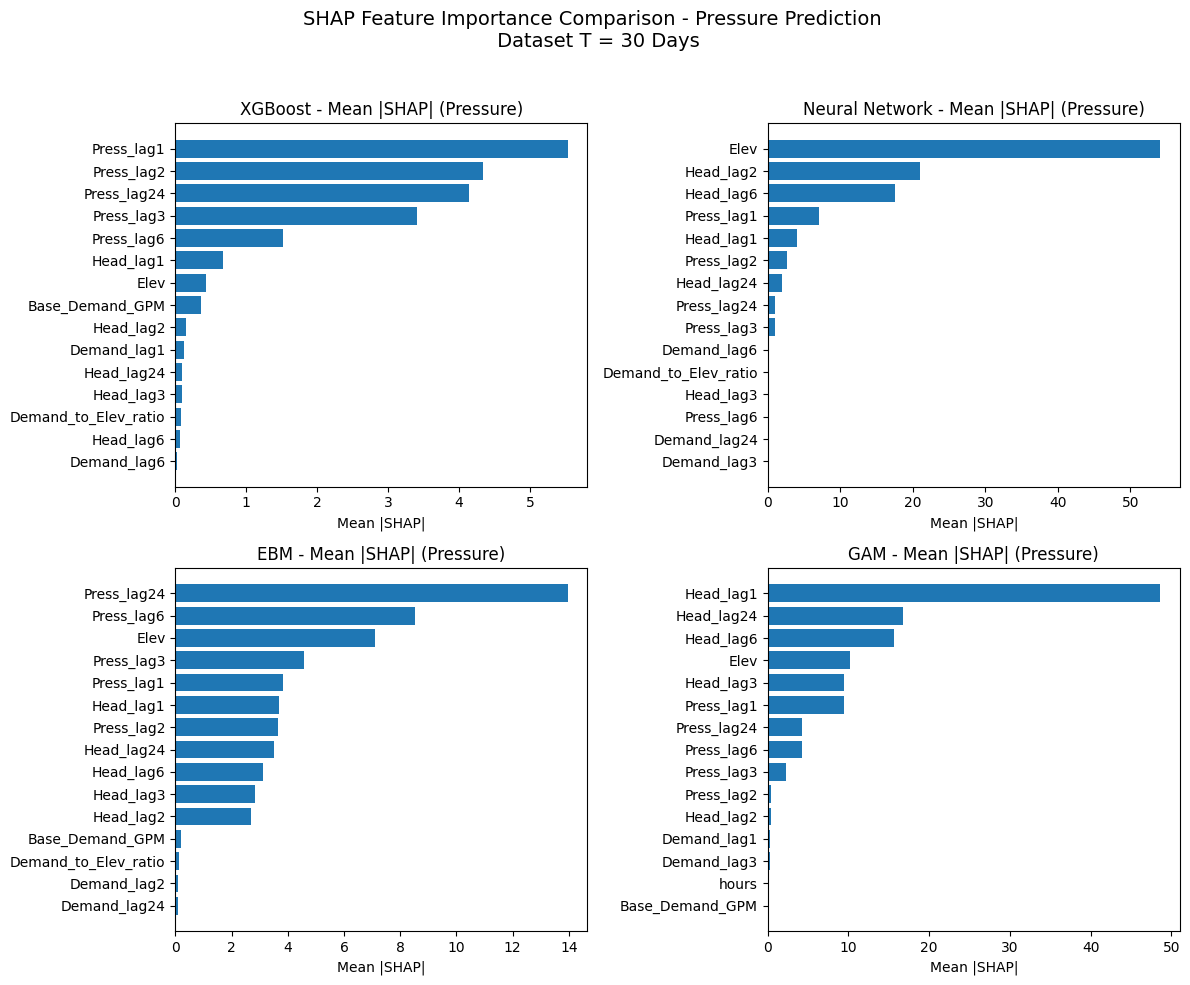

In [37]:
# Combined SHAP bar plot: mean |SHAP| for all four models (Pressure prediction)
import numpy as np
import matplotlib.pyplot as plt

# (name, shap_values) -- reuse the values computed in the cell above
models_shap_bar = [
    ("XGBoost",        shap_values_pressure),
    ("Neural Network", shap_values_nn_pressure),
    ("EBM",            shap_values_ebm_pressure),
    ("GAM",            shap_values_gam_pressure),
]

TOP_N = 15  # number of top features to show per model
feature_names_arr = np.asarray(all_feature_names)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("SHAP Feature Importance Comparison - Pressure Prediction \n Dataset T = 30 Days", fontsize=14)

for ax, (name, sv) in zip(axes.ravel(), models_shap_bar):
    mean_abs = np.abs(np.asarray(sv)).mean(axis=0)          # mean |SHAP| per feature
    order = np.argsort(mean_abs)[::-1][:TOP_N]              # top-N, largest first
    order = order[::-1]                                     # reverse so largest sits on top in barh
    ax.barh(range(len(order)), mean_abs[order], color="#1f77b4")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(feature_names_arr[order])
    ax.set_title(f"{name} - Mean |SHAP| (Pressure)")
    ax.set_xlabel("Mean |SHAP|")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Permutation Importance

Permutation importance measures the decrease in model performance when a single feature's values are randomly shuffled. Unlike built-in feature importance, this method captures the actual impact on predictions and can detect features that are important due to interactions with other features.(Altmann et al., 2010)

Permutation importance analysis further shows the models' dependencies and their alignment with physical principles. The Neural Network exhibits the most substantial maximum decrease in $R^2$ score (~14) when individual features are shuffled, confirming its strong reliance on both elevation and cyclical (24-hour) head lags. This dependence suggests that the NN has successfully internalized the fundamental hydraulic relationship between pressure, elevation, and head, effectively assuming daily cyclical pressure patterns.

Conversely, the XGBoost model shows a much smaller reduction in performance when features are permuted, though it remains heavily dependent on pressure lag features. This reinforces the observation that XGBoost operates primarily on historical performance metrics rather than an underlying physical understanding of hydraulics. In critical infrastructure contexts like water networks, this behavior poses a risk; sensor failures could lead to rapid model collapse. The Neural Network’s reliance on physical parameters like elevation and 24-hour head trends offers a more robust buffer, potentially allowing more time for failure analysis before predictions degrade significantly.

GAM demonstrates a primary reliance on physical elevation, aligning with the hydrostatic pressure formula ($P = \rho g h$). However, its limited emphasis on head lags (compared to elevation) suggests a weaker grasp of the comprehensive hydraulic dynamics relative to the NN.

Finally, the EBM assigns high permutation importance to specific junction identifiers, effectively utilizing them as "pressure benchmarks," even if they lack direct physical prominence. Its lower reliance on head lags compared to the NN implies that EBM's predictive strategy is analogous to XGBoost's, combining past pressure data with these spatial benchmarks rather than fully exploiting hydraulic principles.

C:\Users\kevin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPRegressor was fitted with feature names
  warnings.warn(


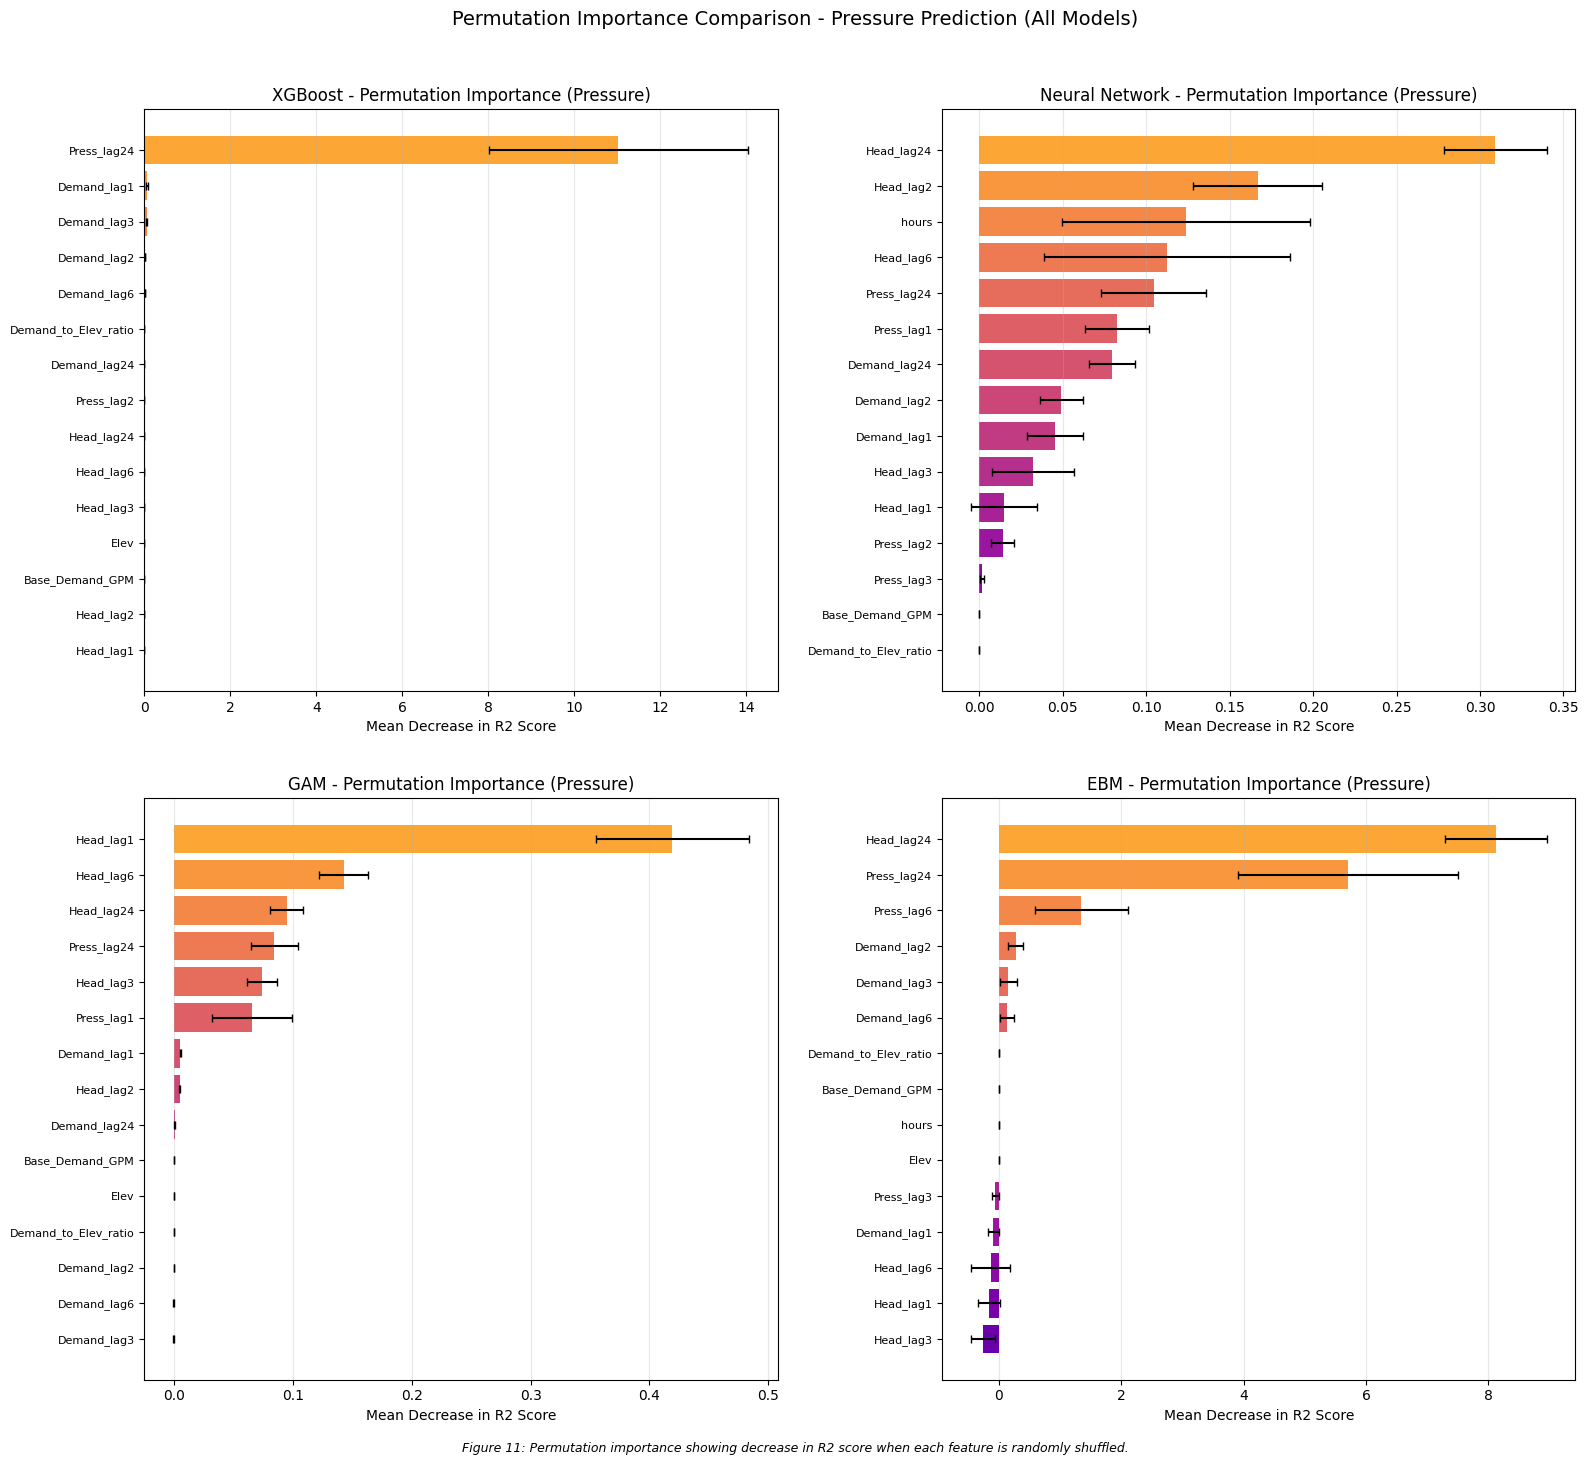

In [28]:
from sklearn.inspection import permutation_importance

# Prepare test subsets
n_perm_samples = 200  # Samples for permutation importance
X_test_subset = X_test.values[:n_perm_samples]
Y_test_pressure = Y_test.iloc[:n_perm_samples]['Pressure [psi]']

# Extract pressure models from each pipeline
xgb_pressure_model = pipe.named_steps['model'].estimators_[0]
nn_pressure_model  = nn_pipe.named_steps['model'].estimators_[0]
gam_pressure_model = gam_pipe.named_steps['model'].estimators_[0]
ebm_pressure_model = ebm_pipe.named_steps['model'].estimators_[0]

# Model configurations (use numpy arrays for all models to avoid feature name mismatches)
model_configs = [
    ('XGBoost',        xgb_pressure_model, X_test_subset),
    ('Neural Network', nn_pressure_model,  X_test_subset),
    ('GAM',            gam_pressure_model, X_test_subset),
    ('EBM',            ebm_pressure_model, X_test_subset),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (model_name, model, X_data) in enumerate(model_configs):
    # Compute permutation importance
    perm_importance = permutation_importance(
        model, X_data, Y_test_pressure,
        n_repeats=10, random_state=42, n_jobs=-1
    )

    # Create DataFrame for plotting
    perm_df = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': perm_importance.importances_mean,
        'Std': perm_importance.importances_std
    }).sort_values('Importance', ascending=True).tail(15)  # Top 15 features

    colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(perm_df)))
    axes[idx].barh(perm_df['Feature'], perm_df['Importance'], xerr=perm_df['Std'],
                   color=colors, capsize=3)
    axes[idx].set_xlabel('Mean Decrease in R2 Score')
    axes[idx].set_title(f'{model_name} - Permutation Importance (Pressure)', fontsize=12)
    axes[idx].tick_params(axis='y', labelsize=8)
    axes[idx].grid(axis='x', alpha=0.3)

plt.suptitle('Permutation Importance Comparison - Pressure Prediction (All Models)', fontsize=14, y=1.02)
plt.figtext(0.5, -0.01, 'Figure 11: Permutation importance showing decrease in R2 score when each feature is randomly shuffled.',
            ha='center', fontsize=9, style='italic', wrap=True)
plt.tight_layout(h_pad=3, w_pad=2)
plt.show()


### Conclusion  

In conclusion, while XGBoost, the Neural Network (NN), and the Explainable Boosting Machine (EBM) all demonstrate strong capabilities in predicting future pressure values, the Neural Network emerges as the superior model. It outperforms the ensemble not only in statistical metrics but also in its adherence to physical realism. By consistently prioritizing features that share a proportional and physically explainable relationship with pressure, the Neural Network offers a robust and reliable tool for water network analysis. 

# References

Almeida, Luis B. "Multilayer perceptrons." Handbook of neural computation. CRC Press, 2020. C1-2.

Altmann A., Toloşi L., Sander O., Lengauer T. (2010). Permutation importance: a corrected feature importance measure, Bioinformatics, Volume 26, Issue 10, Pages 1340–1347, https://doi.org/10.1093/bioinformatics/btq134

Chen, T., & Guestrin, C. (2016). XGBoost: A Scalable Tree Boosting System. In Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, pp. 785-794. https://doi.org/10.1145/2939672.2939785

Friedman, J., Hastie, T., Tibshirani, R. (2000). Additive logistic Regression: A statistical view of boosting. The Annals of Statistics, Vol. 28, No. 2, 337-407, 

Hassija, V., Chamola, V., Mahapatra, A. et al. Interpreting Black-Box Models: A Review on Explainable Artificial Intelligence. Cogn Comput 16, 45–74 (2024). https://doi.org/10.1007/s12559-023-10179-8

Lou, Y., Caruana, R., & Gehrke, J. (2012). Intelligible Models for Classification and Regression. In Proceedings of the 18th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD '12), pp. 150-158. https://doi.org/10.1145/2339530.2339556 

Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. Advances in neural information processing systems, 30. https://arxiv.org/abs/1705.07874

Nori, H., Jenkins, S., Koch, P., & Caruana, R. (2019). InterpretML: A Unified Framework for Machine Learning Interpretability. arXiv preprint arXiv:1909.09223. https://arxiv.org/abs/1909.09223

Ostfeld, A. (2021). 02 Water Sensor Network 1. Battle of the Water Network Models. 3. https://uknowledge.uky.edu/wdst_models/3

Rossman, L. A. (2000). EPANET 2: Users manual. U.S. Environmental Protection Agency.

Simon N. Wood. 2025. Generalized Additive Models. Annual Review Statistics and Its Application. 12:497-526. https://doi.org/10.1146/annurev-statistics-112723-034249

Servén D., Brummitt C. (2018). pyGAM: Generalized Additive Models in Python. Zenodo. DOI: 10.5281/zenodo.1208723